In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import lib_plot


from lib_equations import root_finder, herm_coeff, herm_func, trapezoidal, Simpson


H_6(x) =  -120 + 720x^2 - 480x^4 + 64x^6


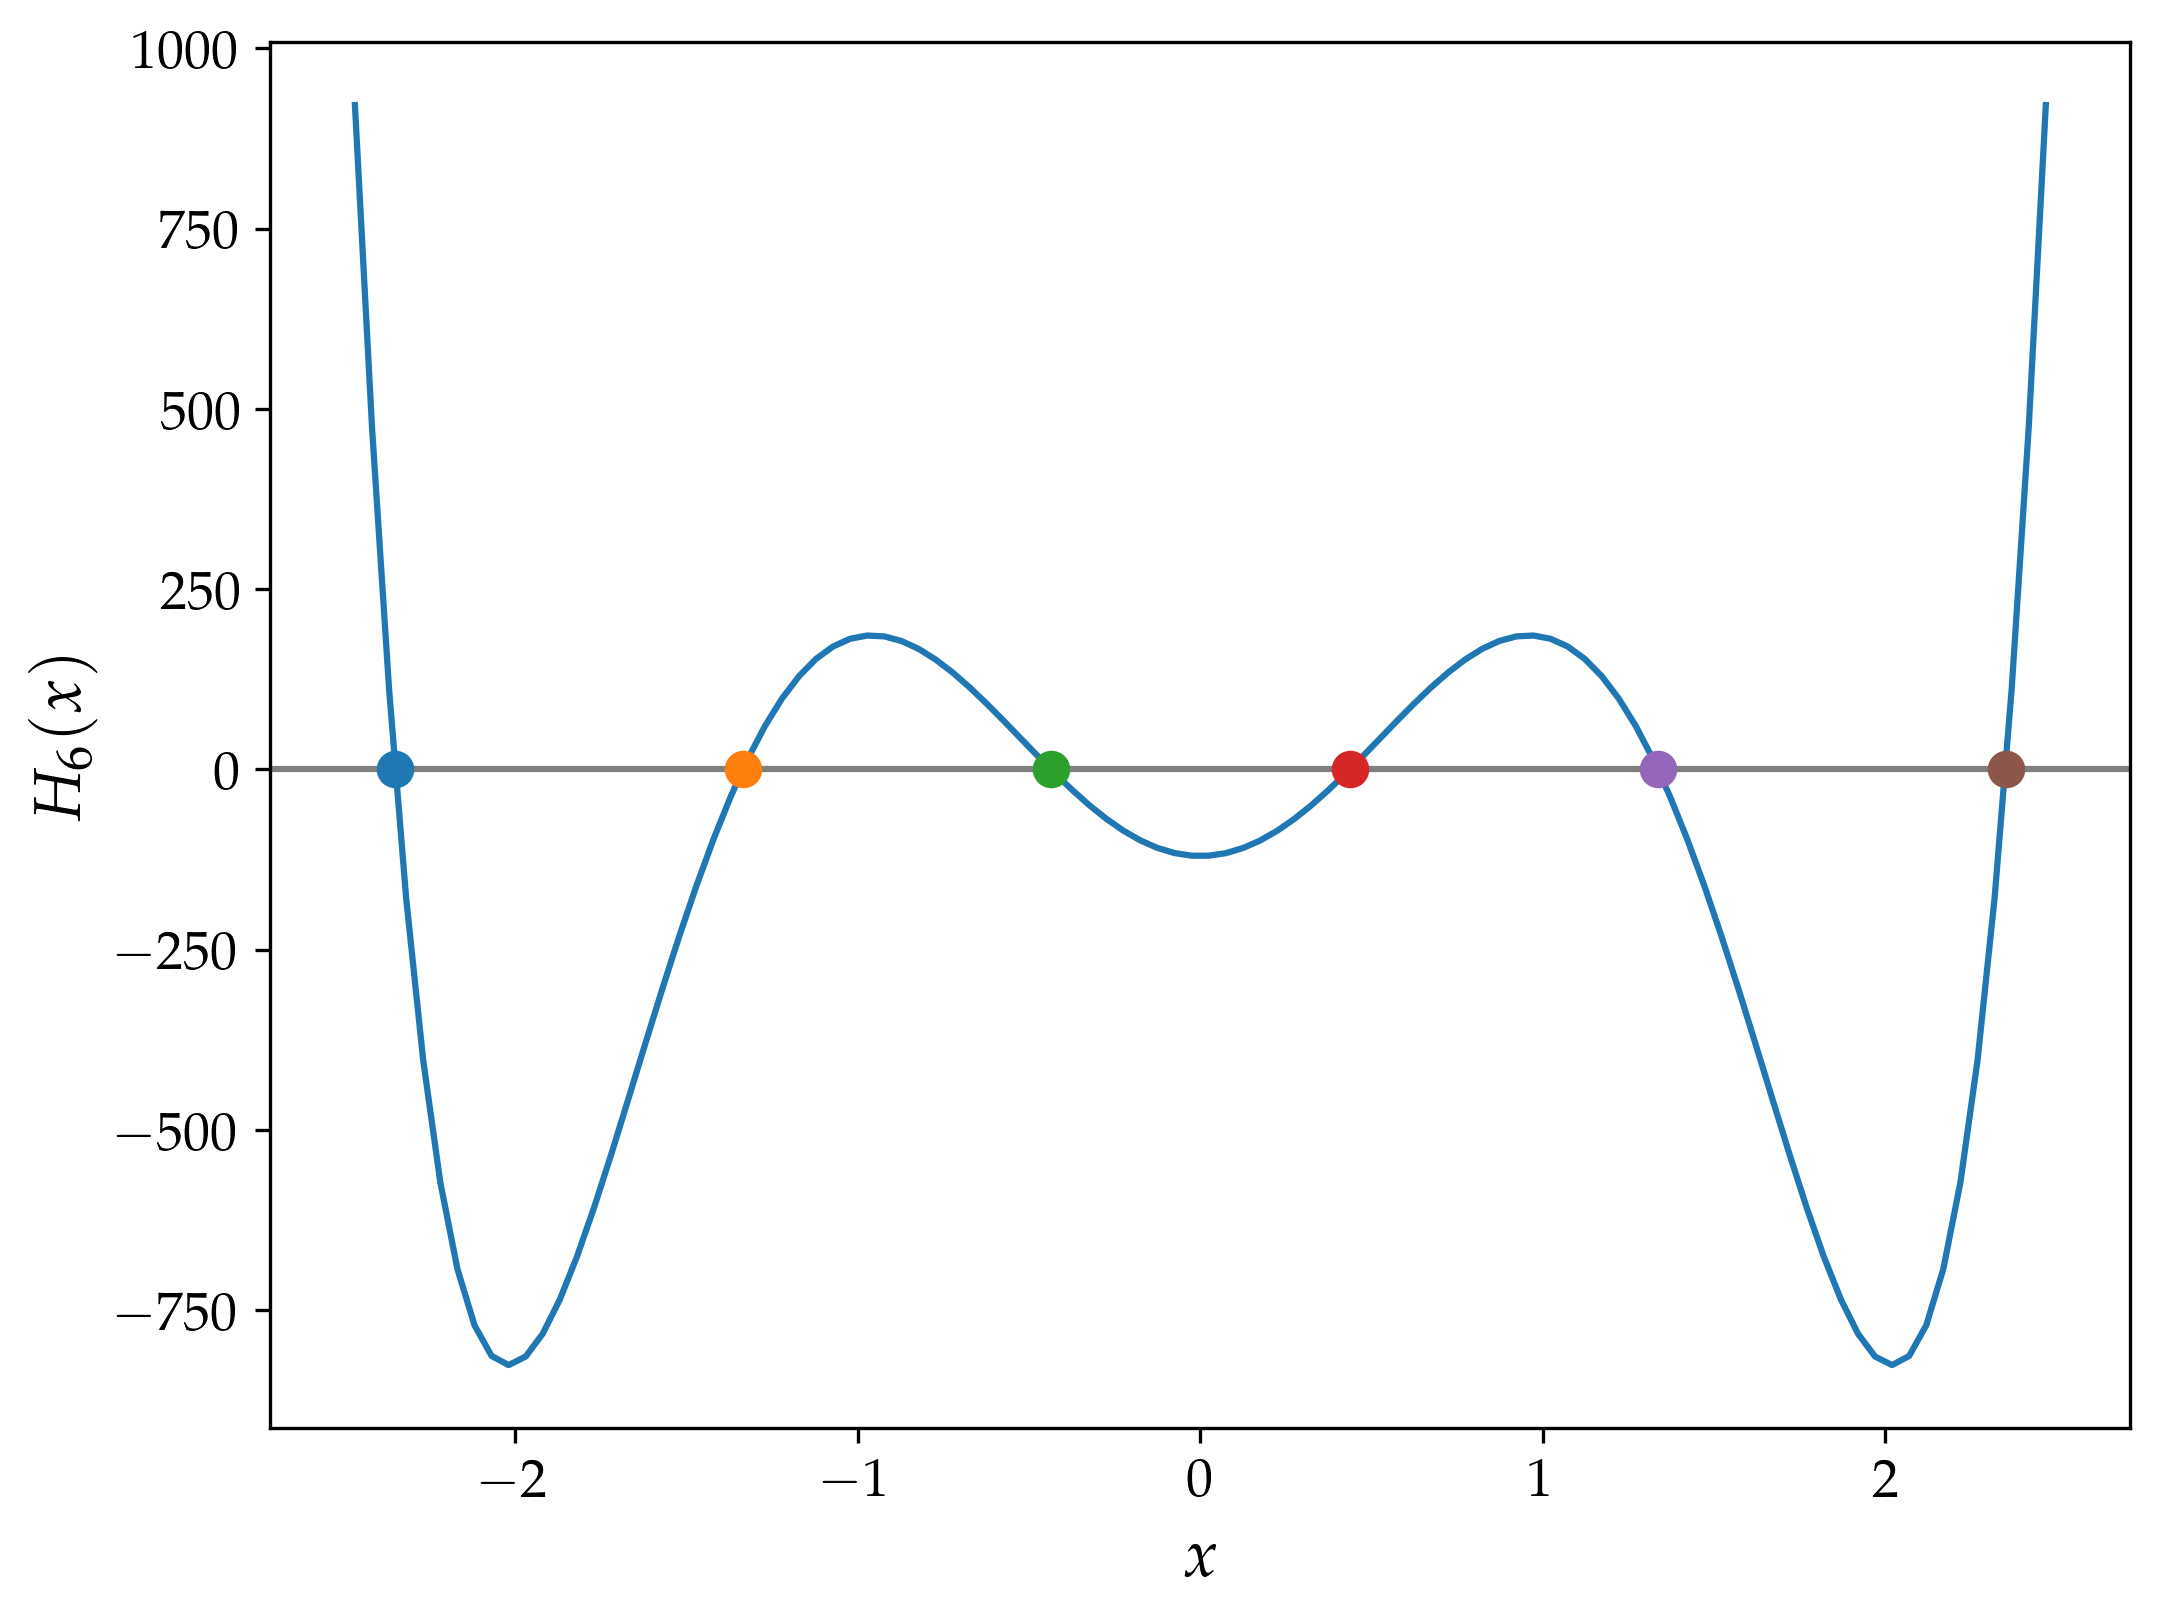

In [2]:
deg = 6
H_coeff = np.flip(herm_coeff(deg))
H_roots = root_finder(herm_coeff(deg))

coeffs = H_coeff
terms = []
for i, c in enumerate(coeffs):
    if np.isclose(c, 0):
        continue
    coeff = int(c) if np.isclose(c, round(c)) else float(c)
    sign = "+" if c > 0 else "-"
    abs_coeff = abs(coeff)
    if i == 0:
        term = f"{abs_coeff}"
    elif i == 1:
        term = f"{abs_coeff}x"
    else:
        term = f"{abs_coeff}x^{i}"
    if terms:
        terms.append(f" {sign} {term}")
    else:
        terms.append(f"{'-' if c < 0 else ''}{term}")
poly_str = "".join(terms) if terms else "0"
print(f'H_{deg}(x) = ', poly_str)

limx = max(H_roots)*1.05
xcoo = np.linspace(-limx, limx, 100, dtype=float)
ycoo = herm_func(xcoo, deg)

plt.plot(xcoo, ycoo)
for i, root in enumerate(H_roots):
    plt.scatter(root, 0, marker='o', zorder=3, lw=3, label=rf'$x_{i}$')

plt.axhline(color='black', alpha=0.5)
plt.ylim()

plt.xlabel(rf'$x$')
plt.ylabel(rf'$H_{deg}(x)$')
# plt.legend()
plt.show()



In [3]:

from lib_equations import H_weigts, Gauss_Herm

func = lambda x: 1 / (1+x**2)

deg = 15
xcoo = root_finder(herm_coeff(deg))
ycoo = H_weigts(xcoo, deg)

res = Gauss_Herm(func, deg)
print(f'Result (n={deg}) = ', res)


Result (n=15) =  1.3435830685093837


<unknown>:531: SyntaxWarning: invalid escape sequence '\i'


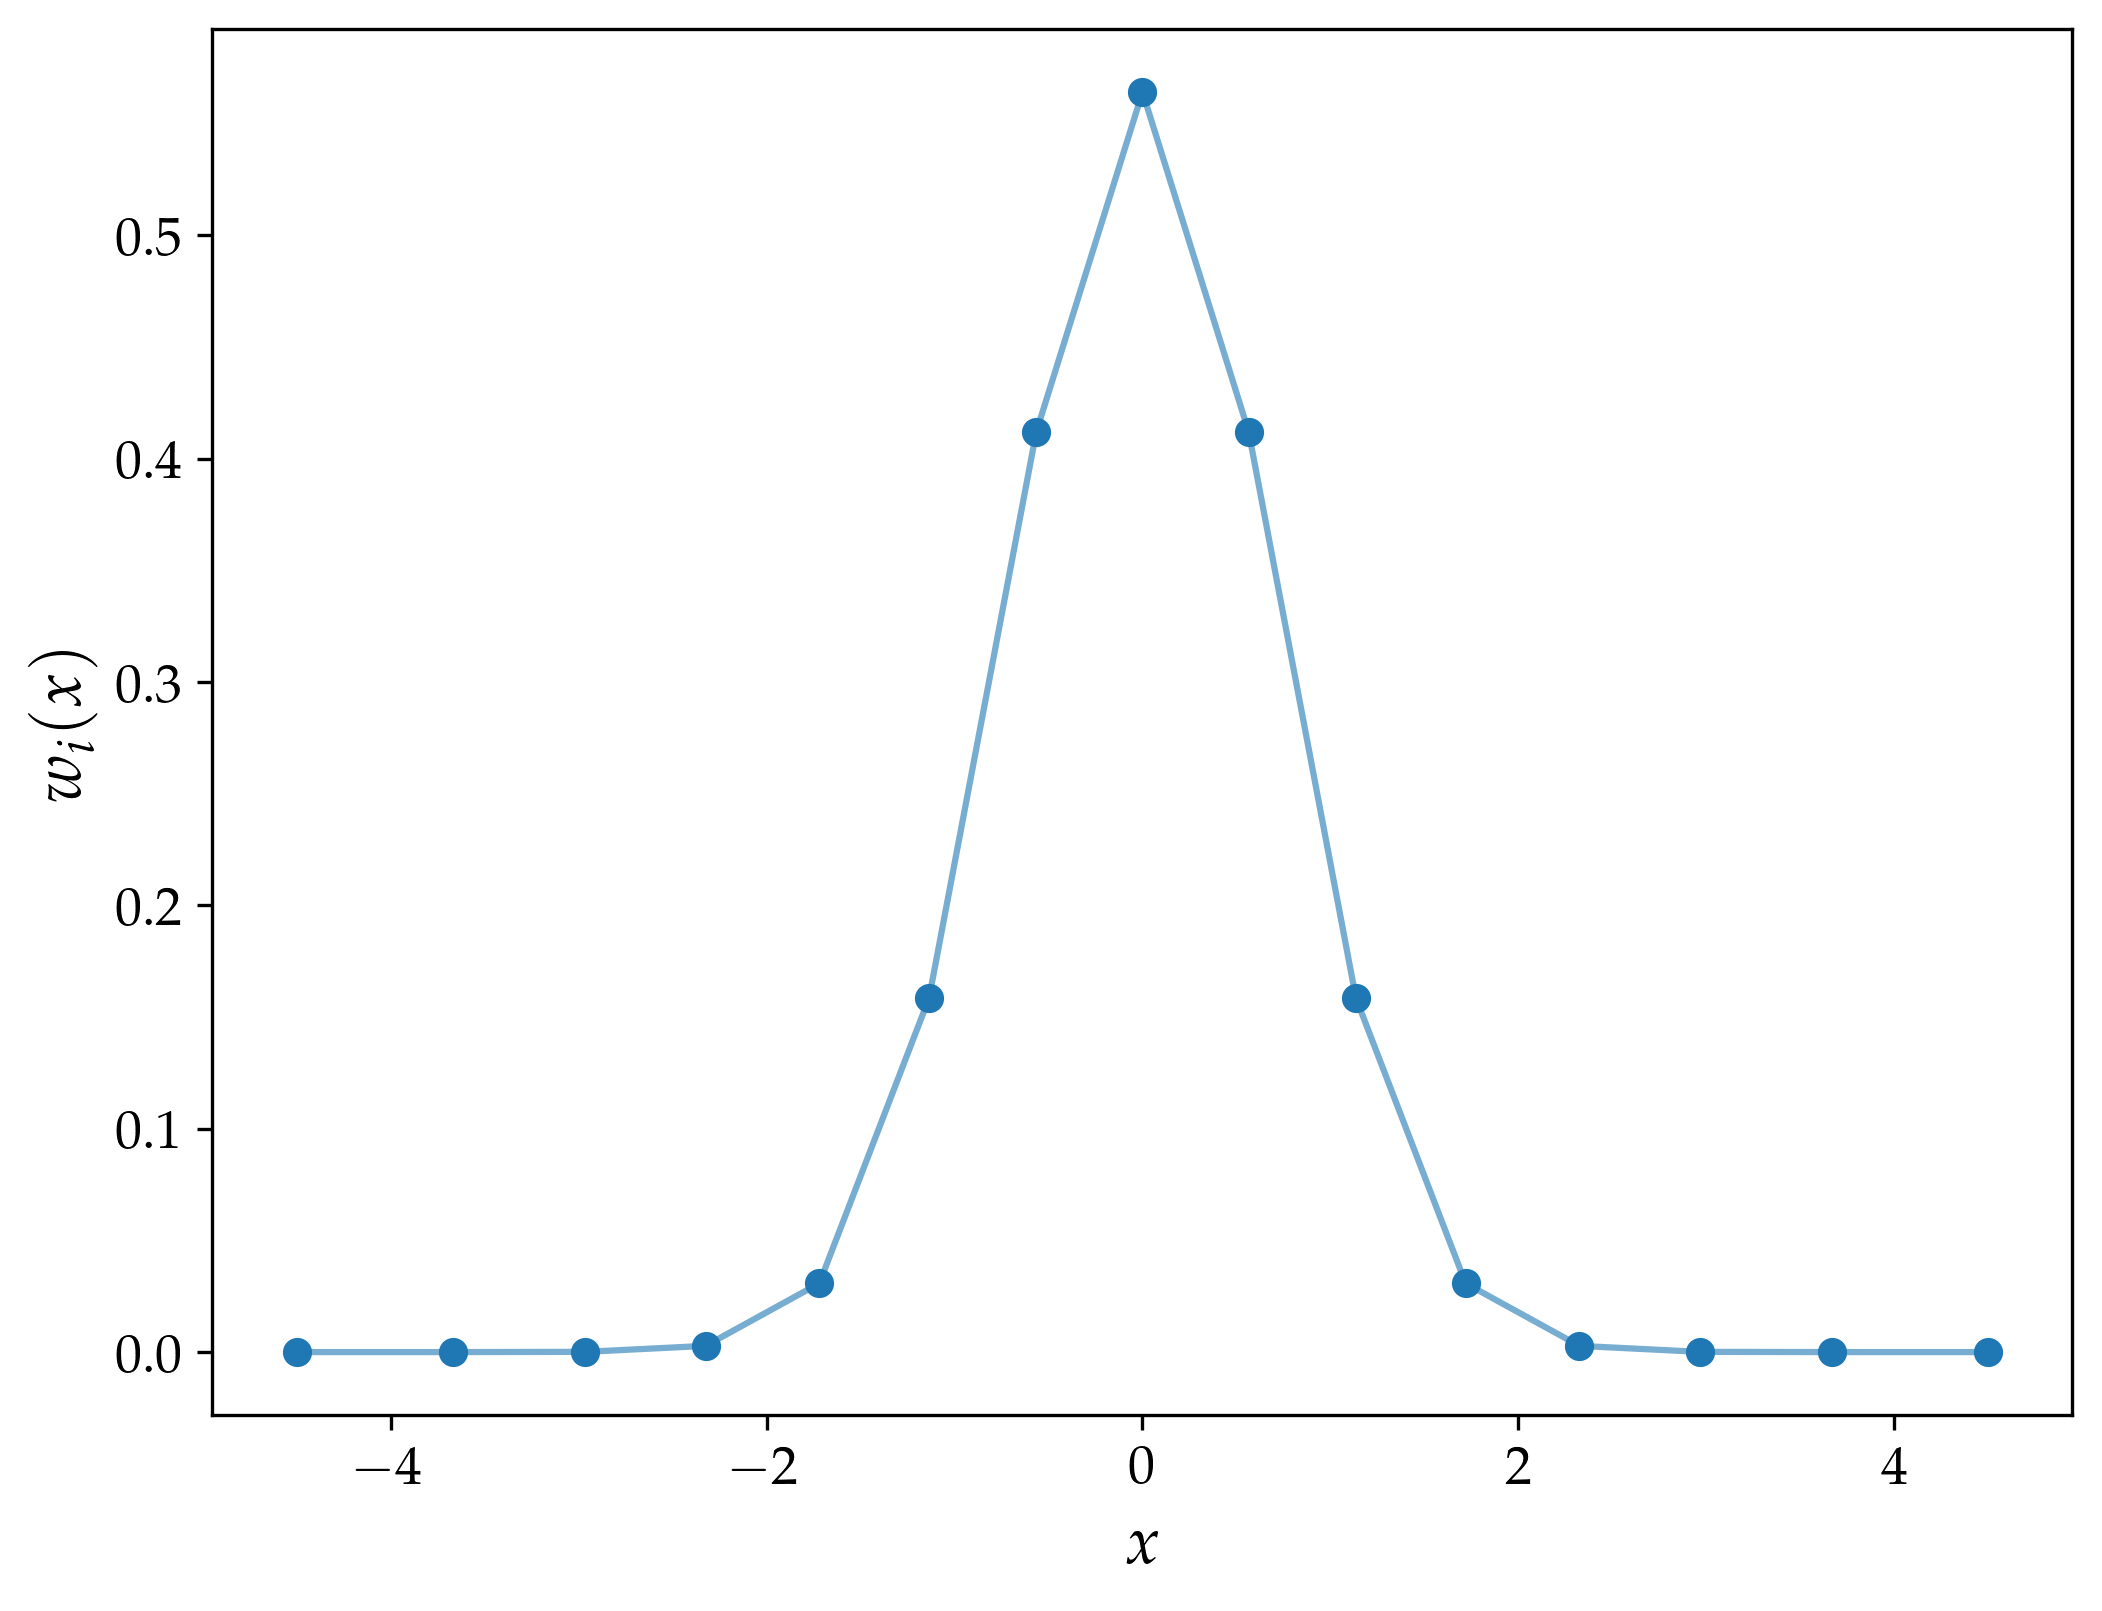

In [4]:

plt.plot(xcoo, ycoo, alpha=0.6)
plt.scatter(xcoo, ycoo, zorder=3, label='Radici ')
plt.xlabel(r'$x$')
plt.ylabel(rf'$w_i(x)$')

plt.savefig('plots/width_example.png')
plt.show()


In [5]:
true = np.e * np.pi * math.erfc(1)

n_deg = np.arange(1, 21, 2)
errs_1 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_1.append(err)


n --> res:
    1  -->   1.7724538509055159
       -->   4.3e-01

    3  -->   1.4179630807244217
       -->   7.5e-02

    5  -->   1.3634260391580975
       -->   2.0e-02

    7  -->   1.3500262746454854
       -->   6.7e-03

    9  -->   1.3458700894018611
       -->   2.6e-03

    11 -->   1.3443774750554012
       -->   1.1e-03

    13 -->   1.343783187410203
       -->   4.9e-04

    15 -->   1.3440373525627565
       -->   7.4e-04

    17 -->   1.3434100820857953
       -->   1.2e-04

    19 -->   -0.000248011785337722
       -->   1.3e+00



c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:525: RuntimeWarning: overflow encountered in scalar multiply
  num = 2**(n-1) * factorial(n-1) * np.sqrt(np.pi)


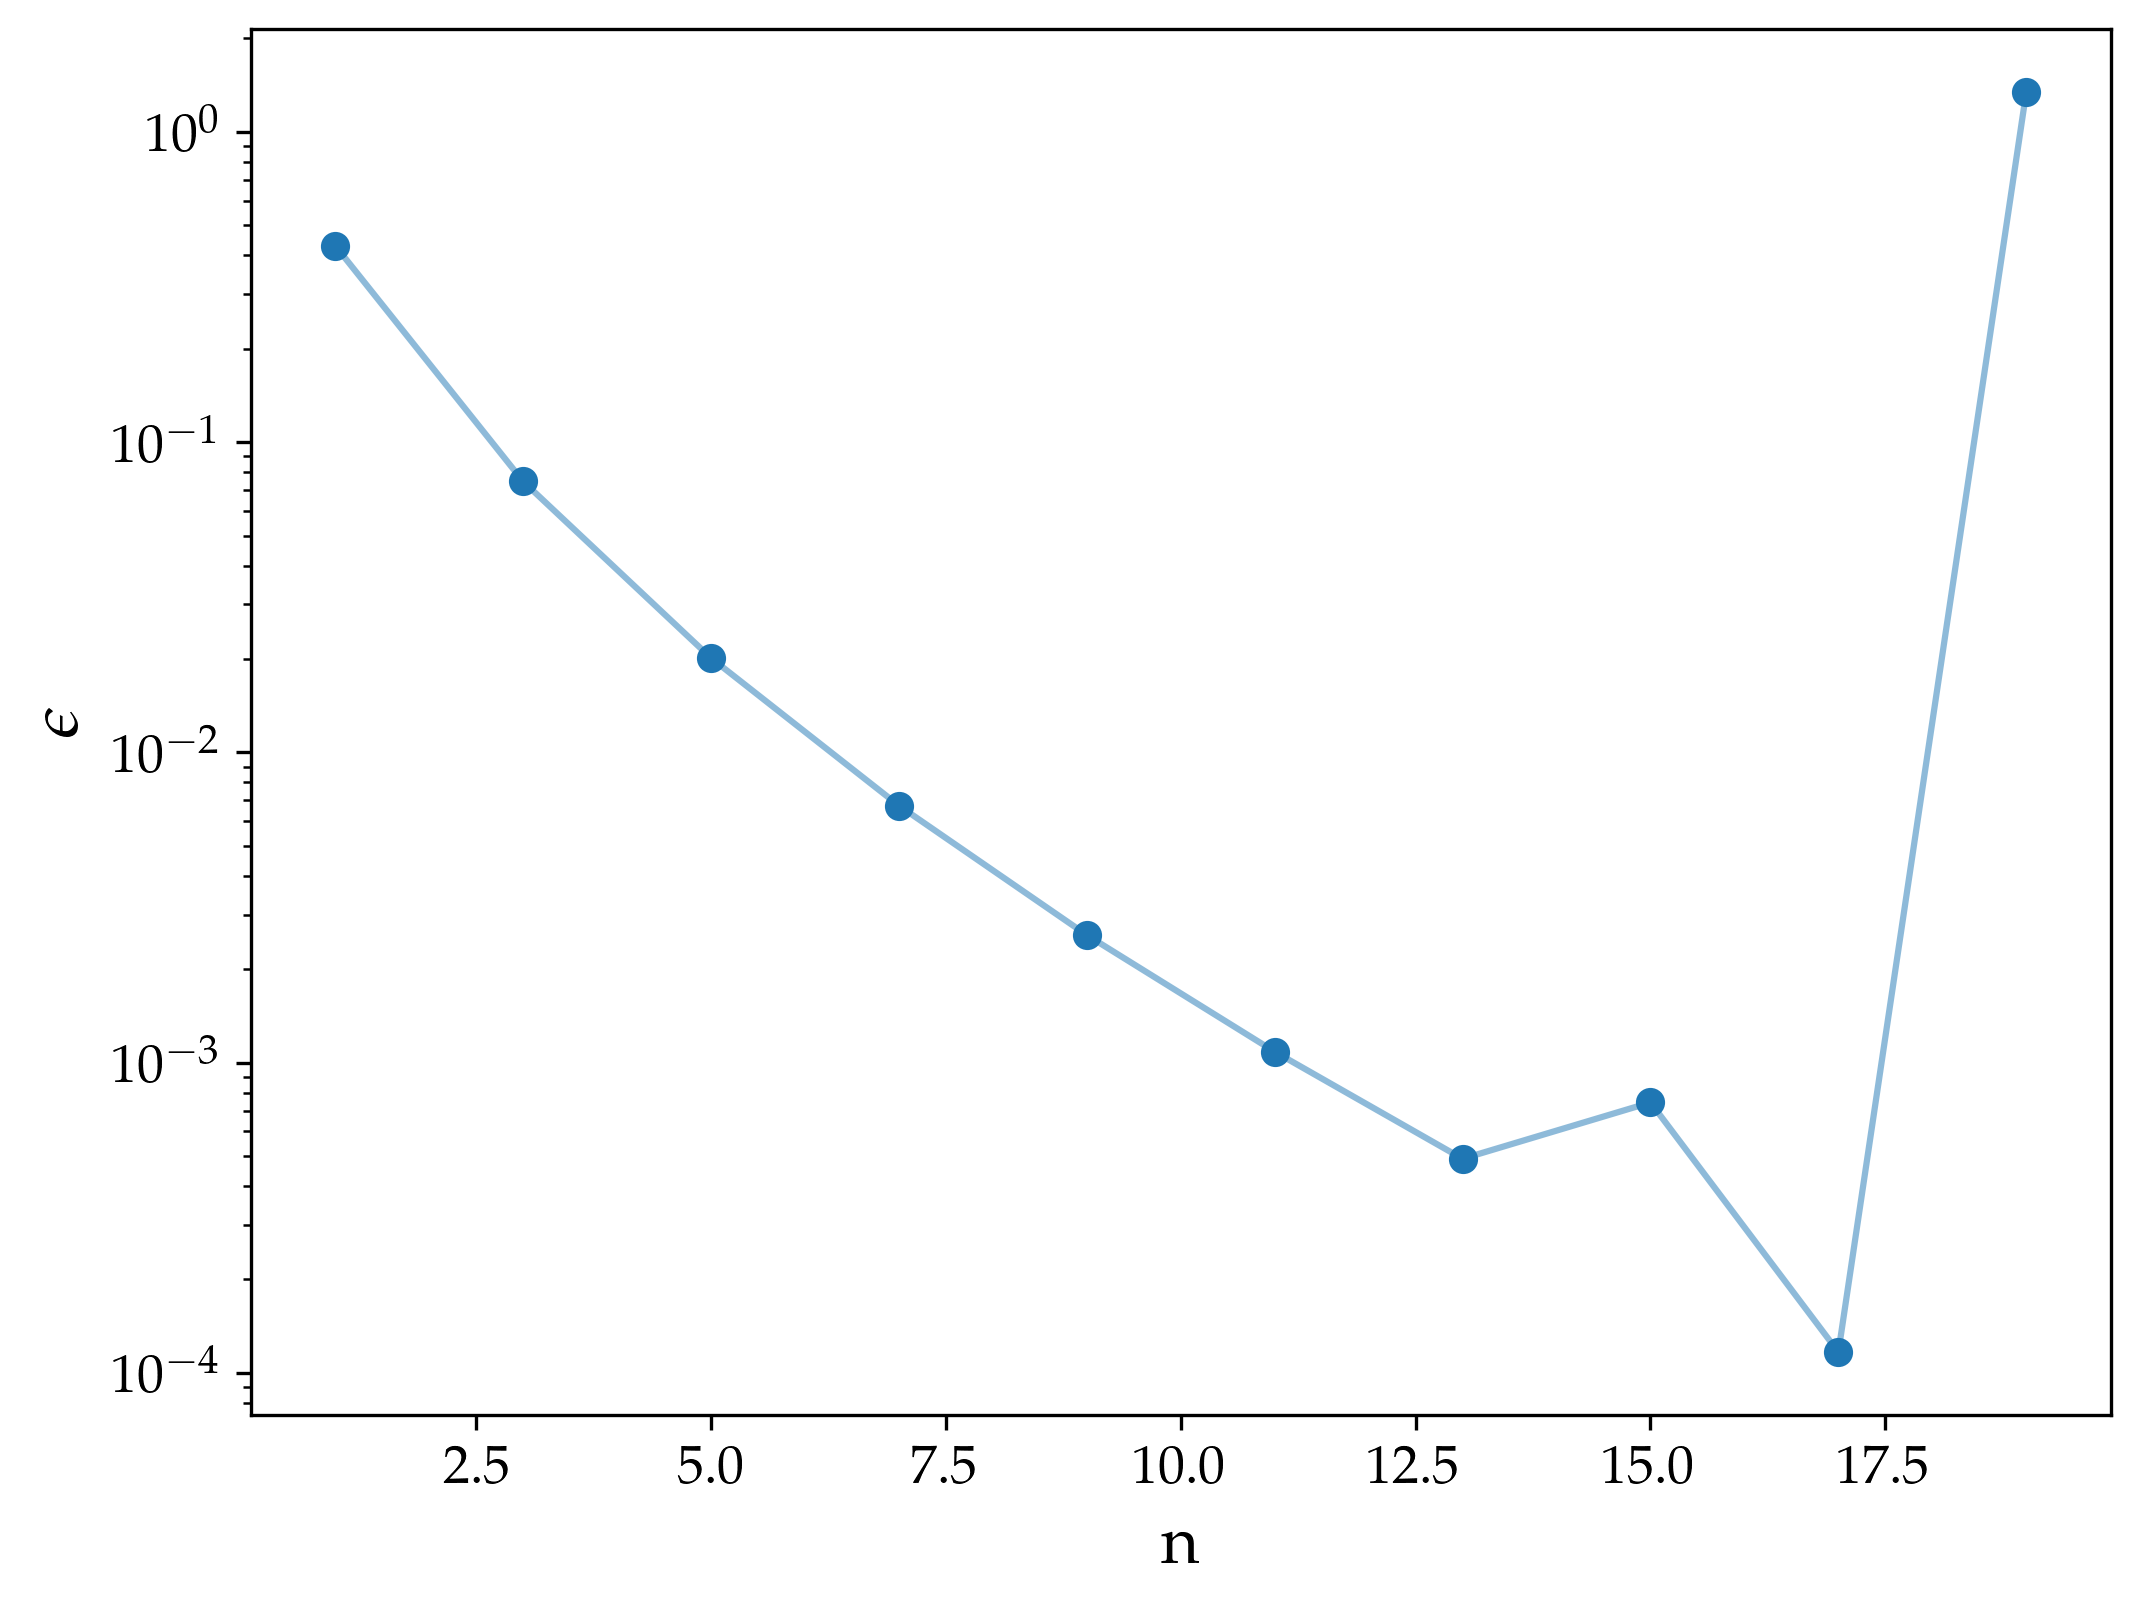

In [6]:
plt.plot(n_deg, errs_1, alpha=0.5)
plt.scatter(n_deg, errs_1)
plt.xlabel(rf'n')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_1.png')
plt.show()


n --> res:
    1  -->   0.0
       -->   5.8e+00

    3  -->   1.4955079367024195
       -->   4.3e+00

    5  -->   5.8158641982861115
       -->   2.4e-12

    7  -->   5.8158641982842925
       -->   5.7e-13

    9  -->   5.815864198284064
       -->   3.4e-13

    11 -->   5.815864198285704
       -->   2.0e-12

    13 -->   5.815864252877294
       -->   5.5e-08

    15 -->   5.815271116380772
       -->   5.9e-04

    17 -->   6.342213882988037
       -->   5.3e-01

    19 -->   -0.0010721450493534487
       -->   5.8e+00



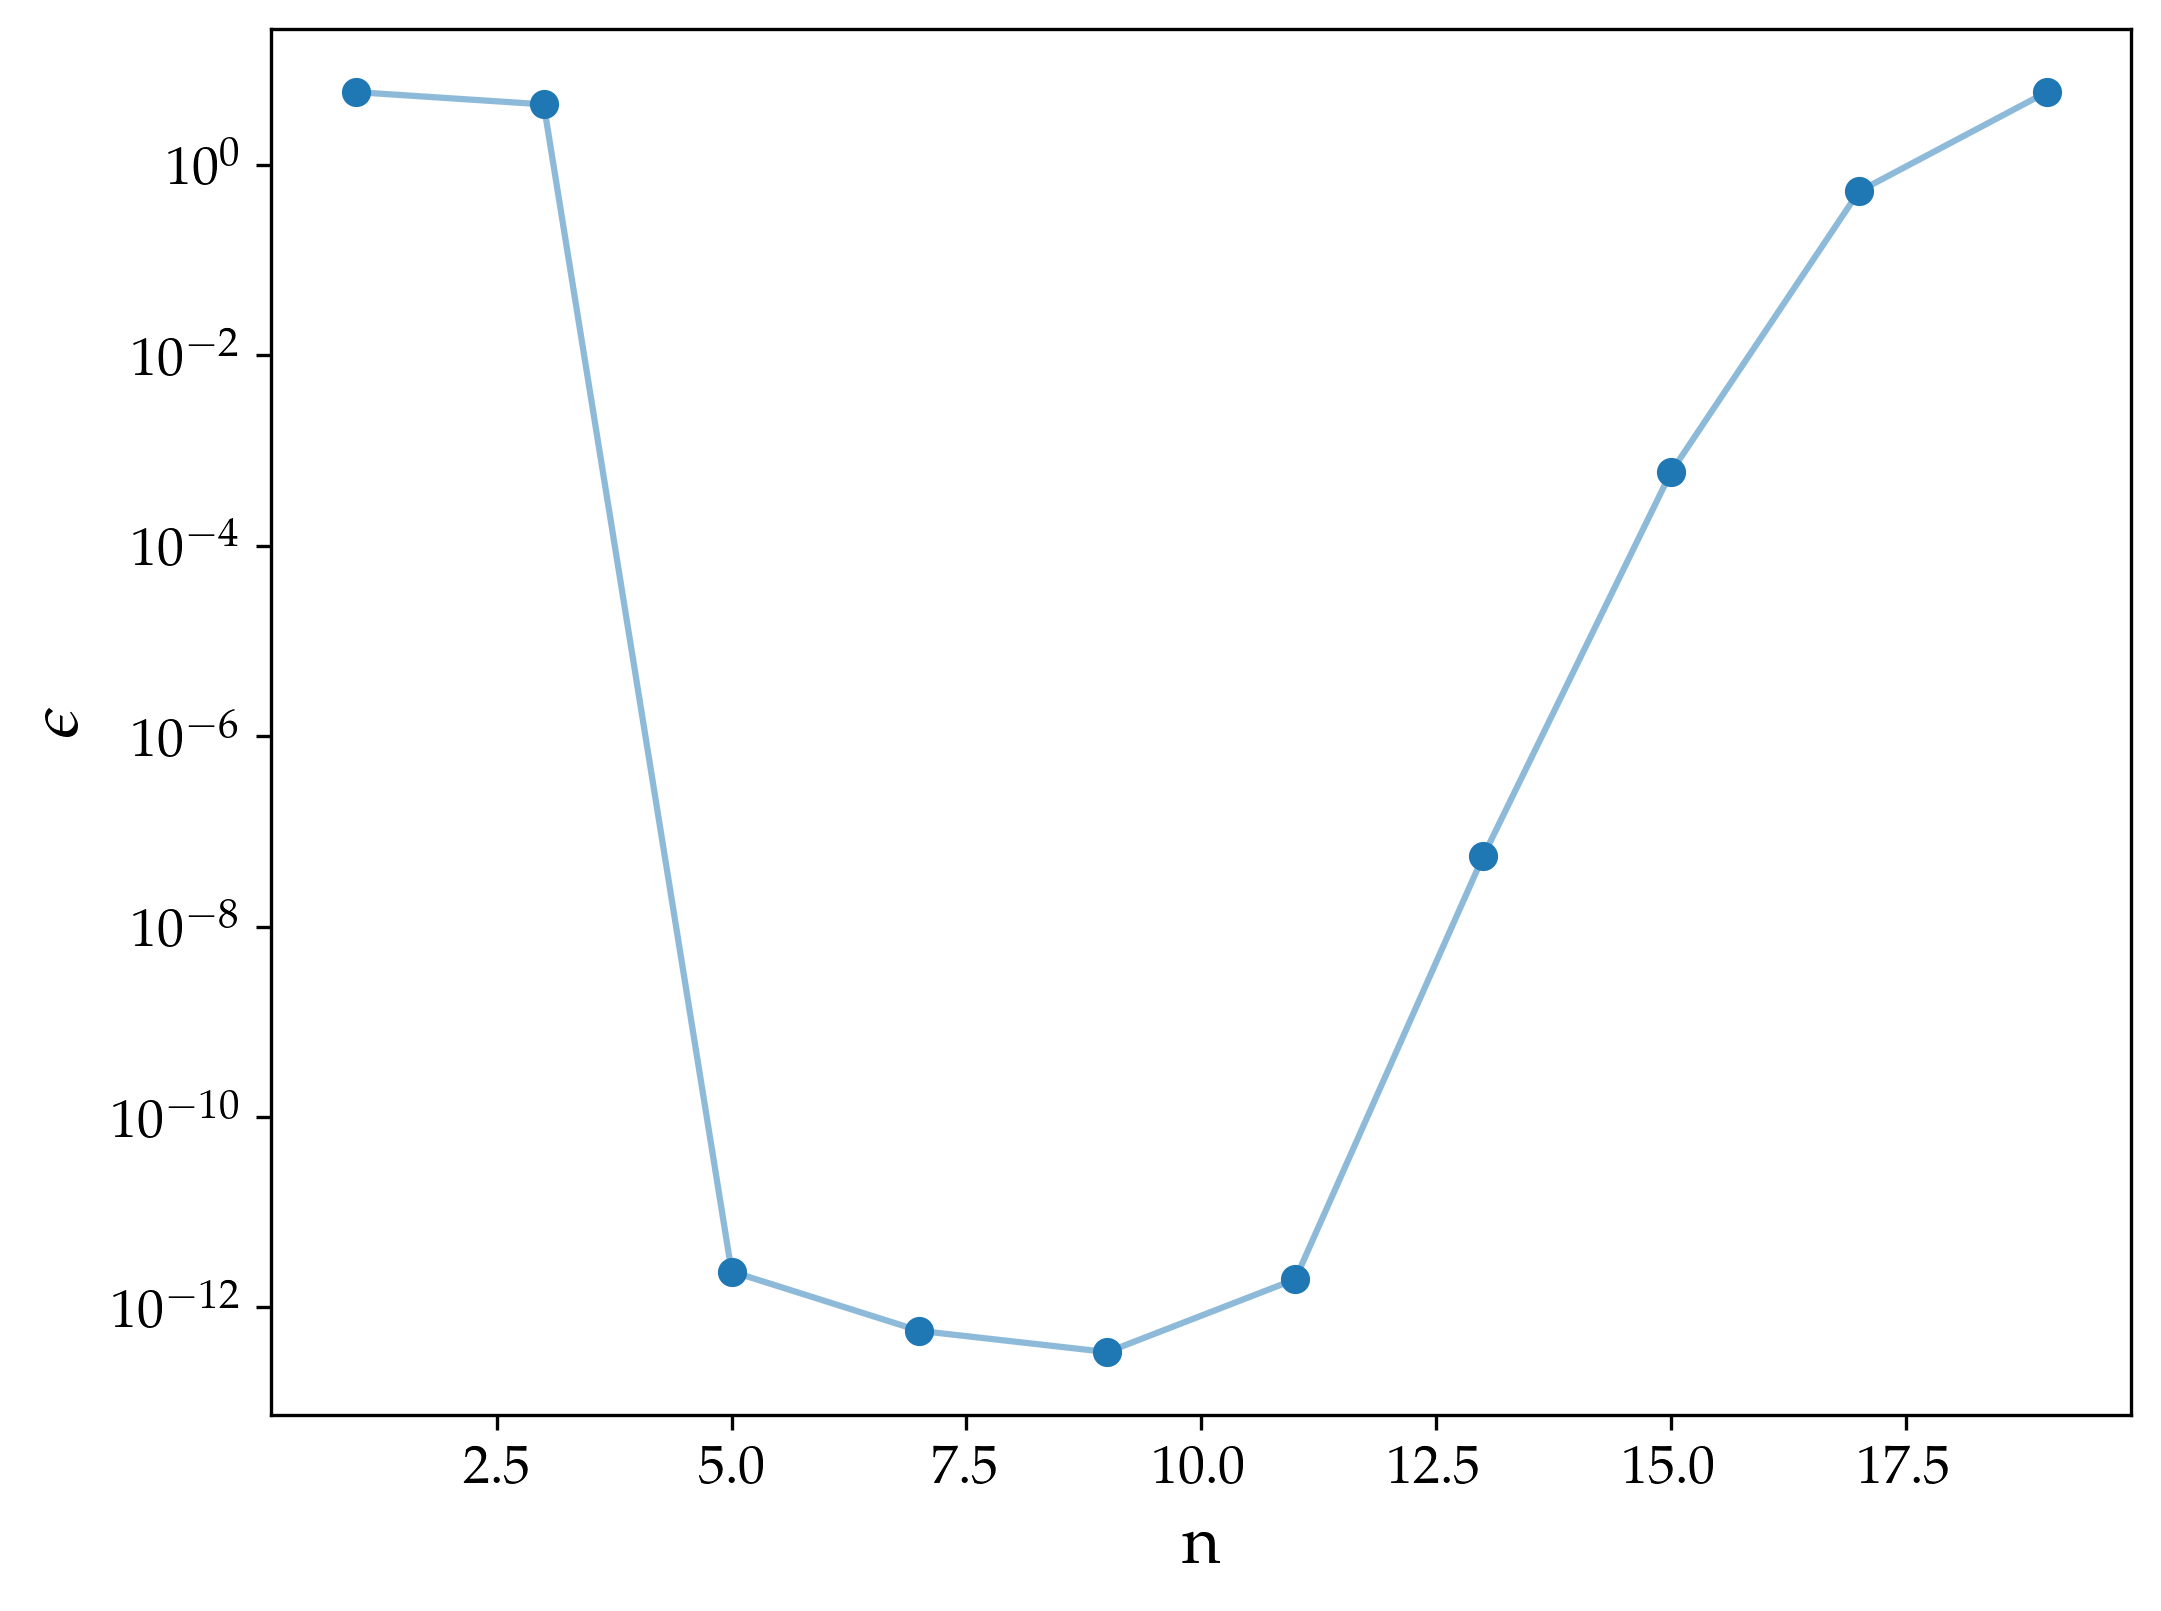

In [7]:
func = lambda x: 1/2 * x**8
true = 105/32 * np.sqrt(np.pi)

errs_2 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_2.append(err)

plt.plot(n_deg, errs_2, alpha=0.5)
plt.scatter(n_deg, errs_2)
plt.xlabel(rf'n')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_2.png')
plt.show()


## **The case of interest of $\int_3 ^\infty dx\ x^5 e^{-x^2}$**

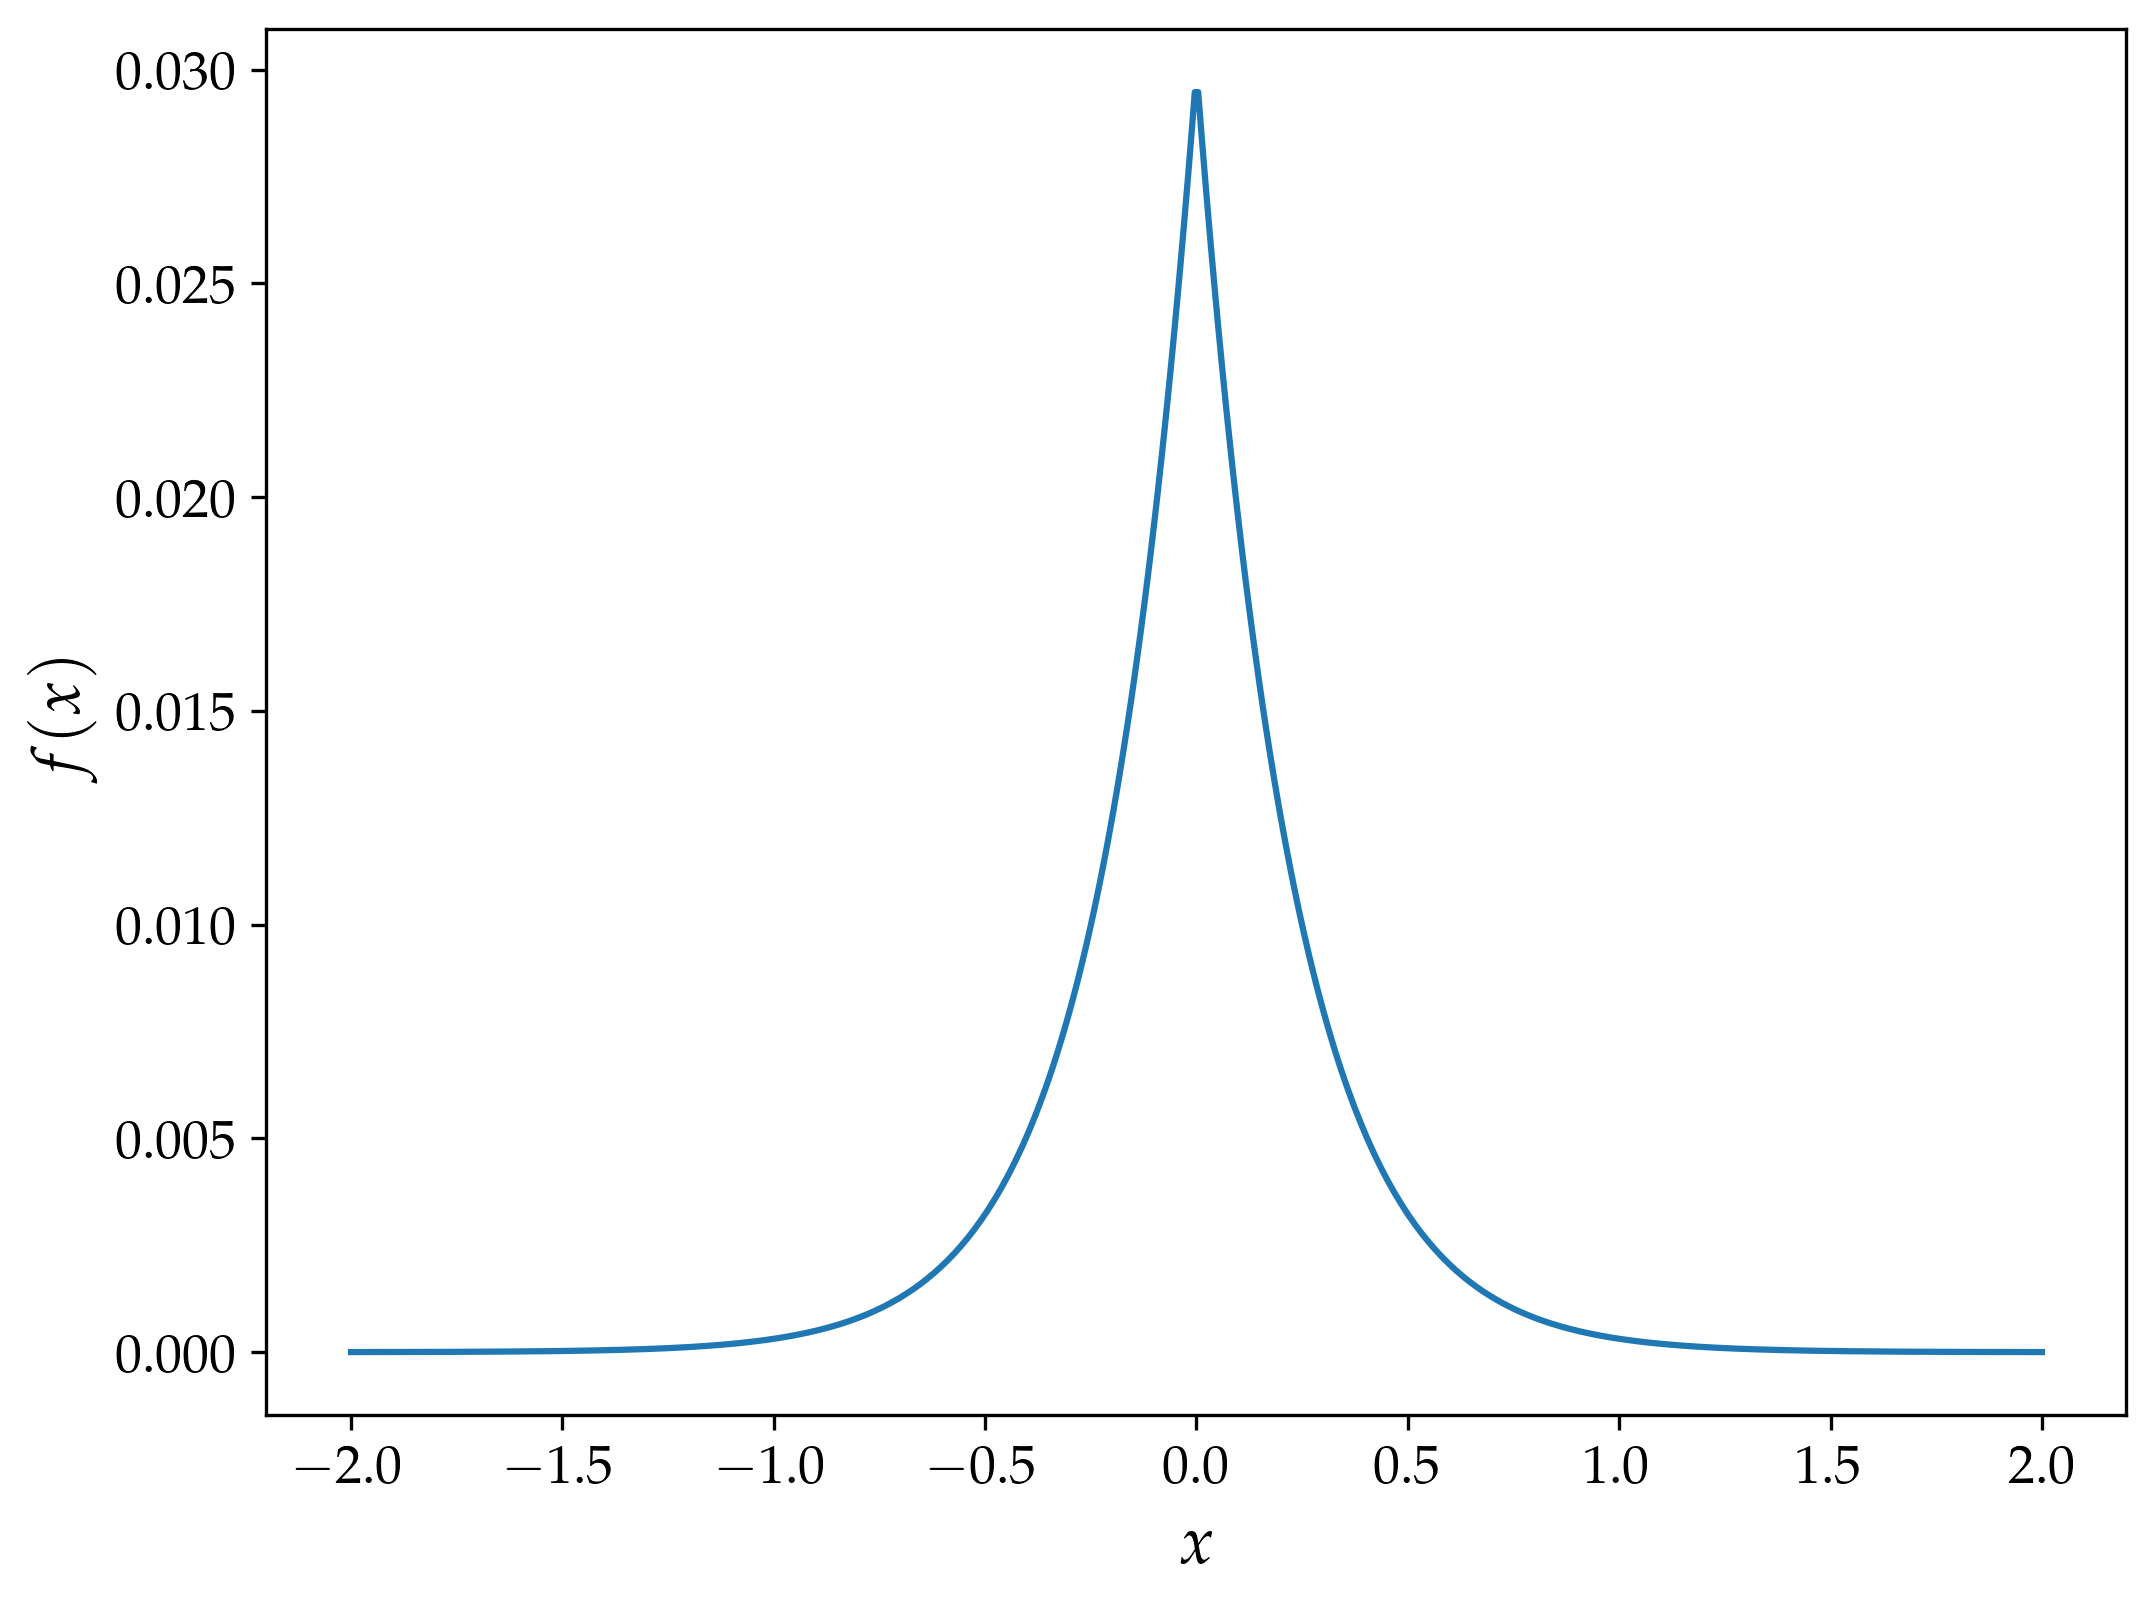

In [15]:
func = lambda x: (np.abs(x)+3)**5 * np.exp(-6*np.abs(x) - 9)
true = 101*np.exp(-9) / 2 
n_deg = np.arange(1, 23, 2)

xmax = 2
xcoo = np.linspace(-xmax, xmax, 500)
ycoo = func(xcoo)

plt.plot(xcoo, ycoo)
# plt.yscale('log')
plt.xlabel(rf'$x$')
plt.ylabel(rf'$f(x)$')

plt.savefig('plots/func_display.png')
plt.show()


n --> res:
    1  -->   0.053153378345782105
       -->   4.7e-02

    3  -->   0.03549874033202752
       -->   2.9e-02

    5  -->   0.02864870001044485
       -->   2.2e-02

    7  -->   0.02493465032452093
       -->   1.9e-02

    9  -->   0.022599812246662923
       -->   1.6e-02

    11 -->   0.020997220843576643
       -->   1.5e-02

    13 -->   0.019829972760983368
       -->   1.4e-02

    15 -->   0.018942390320293385
       -->   1.3e-02

    17 -->   0.018244991543081873
       -->   1.2e-02

    19 -->   -3.2646061759850973e-06
       -->   6.2e-03

    21 -->   5.8260738946551335e-08
       -->   6.2e-03



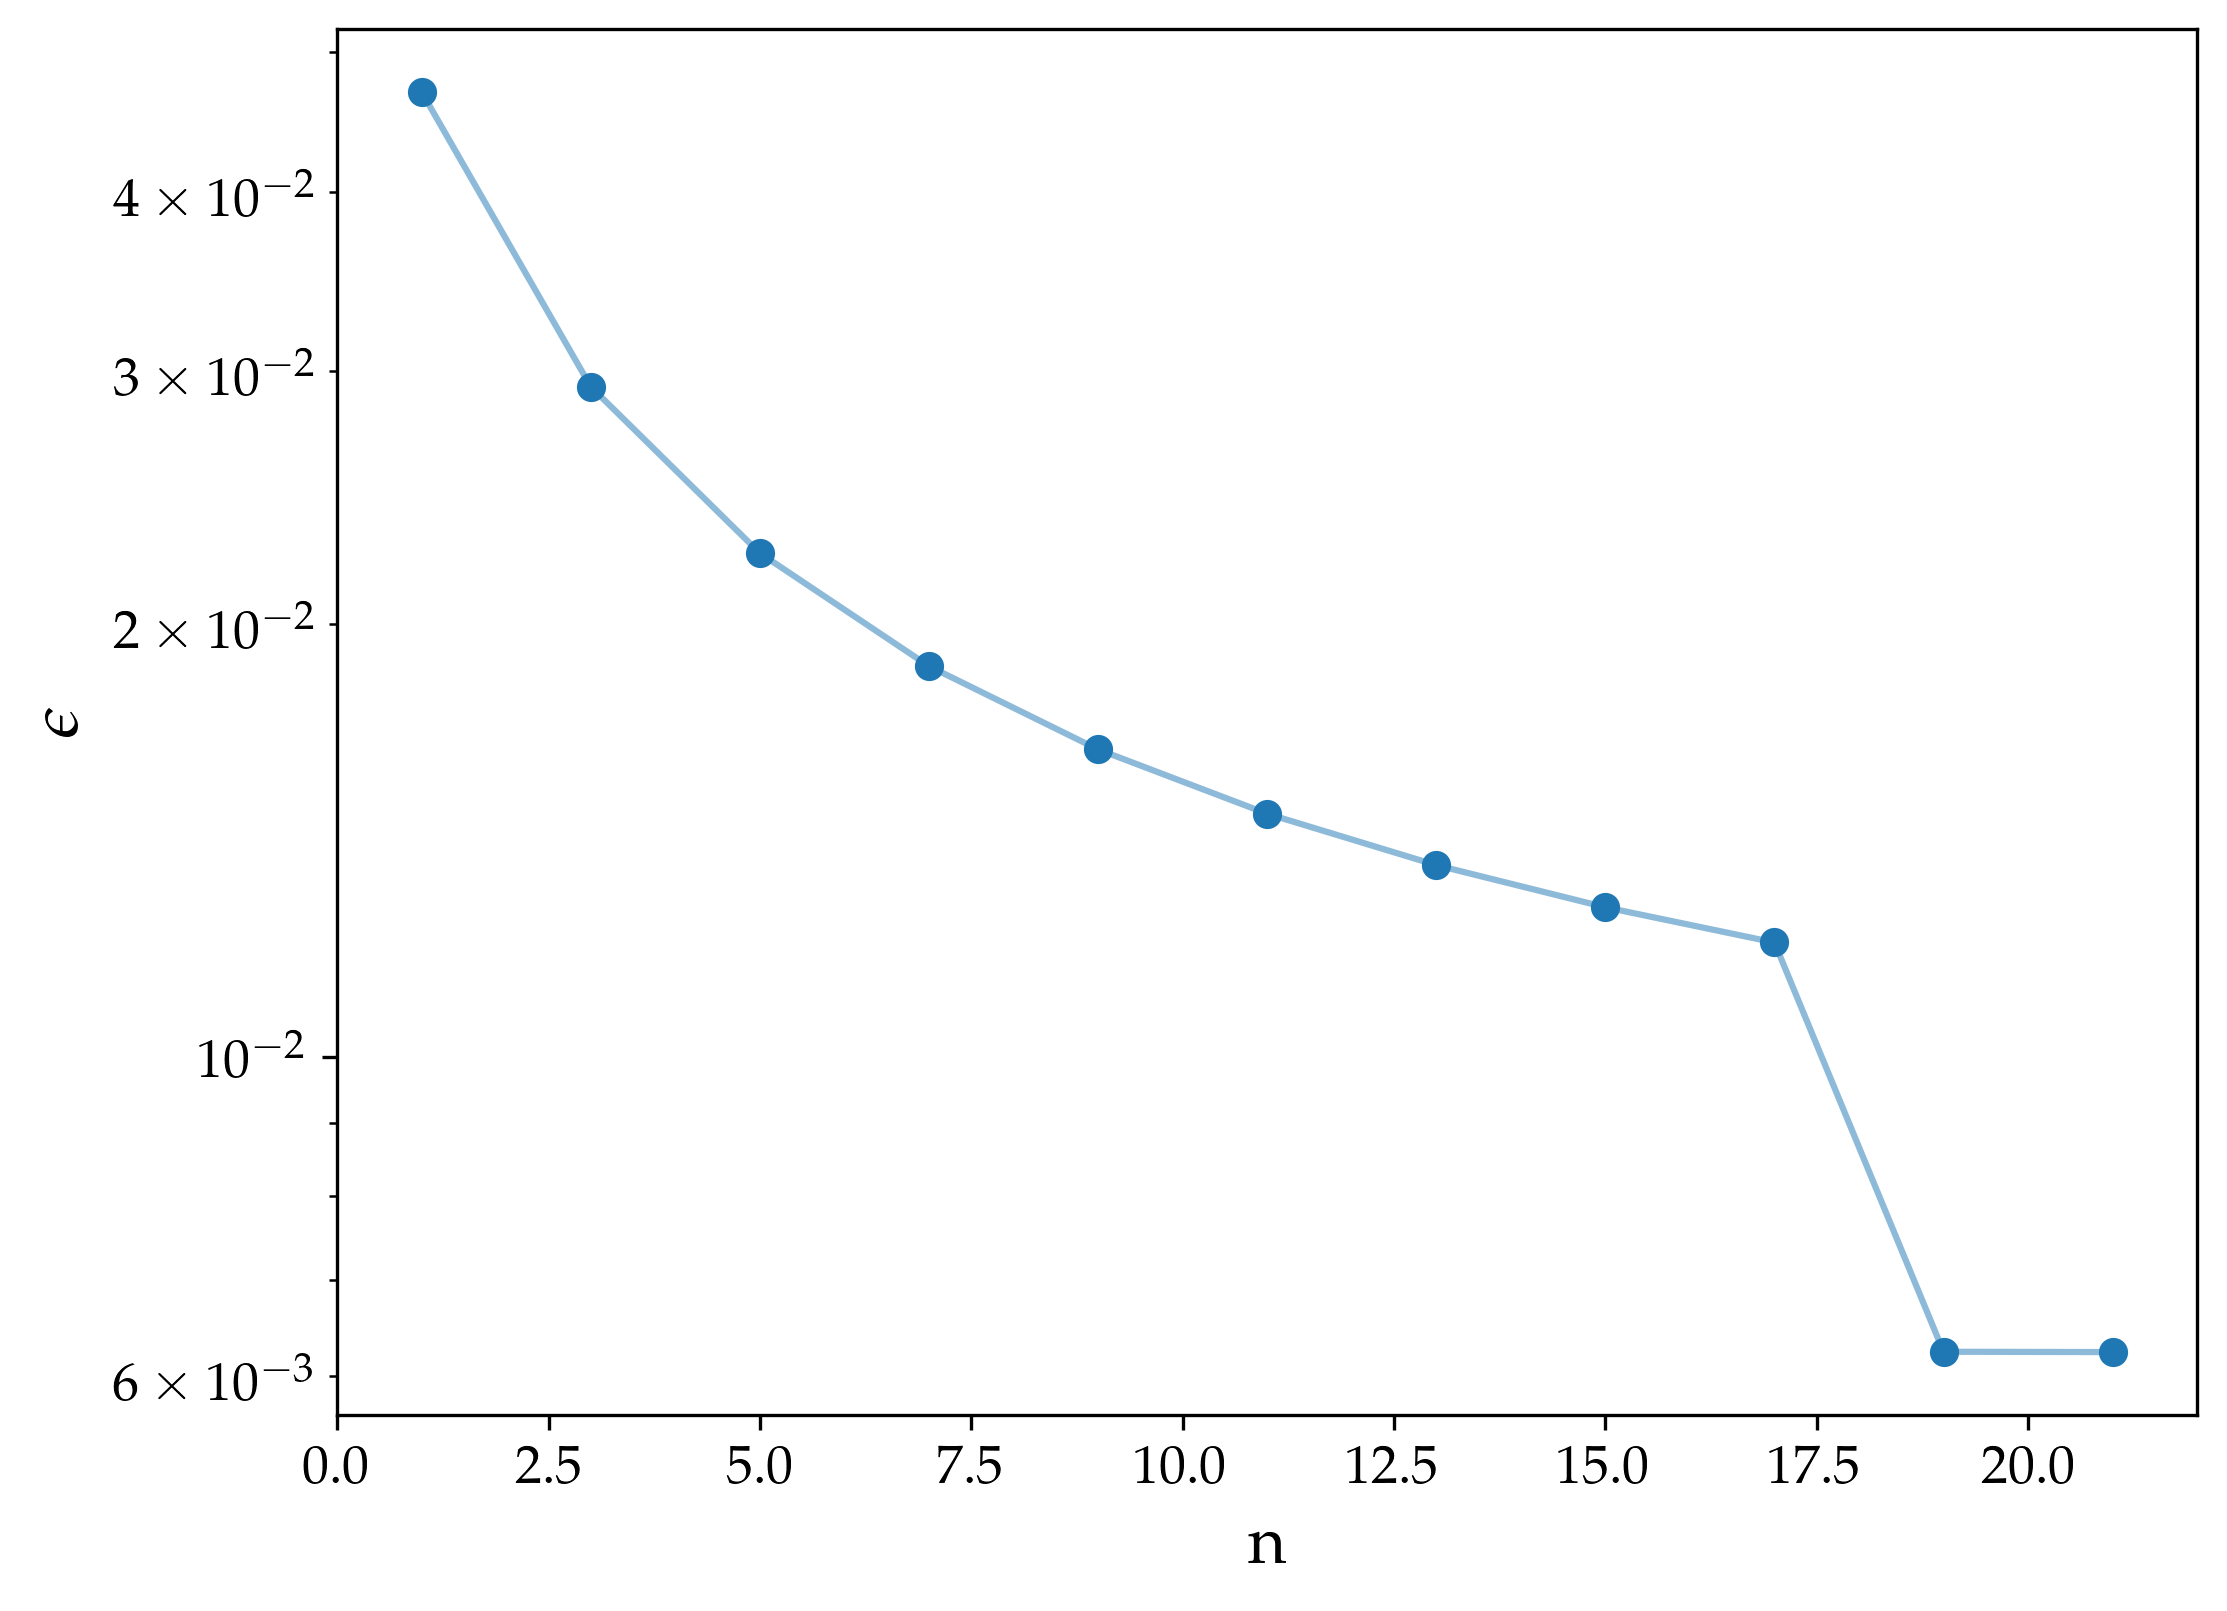

In [9]:

errs_3 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_3.append(err)

plt.plot(n_deg, errs_3, alpha=0.5)
plt.scatter(n_deg, errs_3)
plt.xlabel(rf'n')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_3.png')
plt.show()


In [10]:

errs_3_trap = []
errs_3_sim = []
for deg in n_deg:

    res = trapezoidal(func, -xmax, xmax, 2*xmax/ deg)
    print('dx =', 2*xmax/ deg)
    err = abs(res - true)
    errs_3_trap.append(err)
    
    res = Simpson(func, -xmax, xmax, 2*xmax/ deg)
    err = abs(res - true)
    errs_3_sim.append(err)

names = [
    'Gaussian quadrature',
    'Trapezoidal',
    'Simpson'
]

markers = ['o', '*', 'x']


dx = 4.0
dx = 1.3333333333333333
dx = 0.8
dx = 0.5714285714285714
dx = 0.4444444444444444
dx = 0.36363636363636365
dx = 0.3076923076923077
dx = 0.26666666666666666
dx = 0.23529411764705882
dx = 0.21052631578947367
dx = 0.19047619047619047


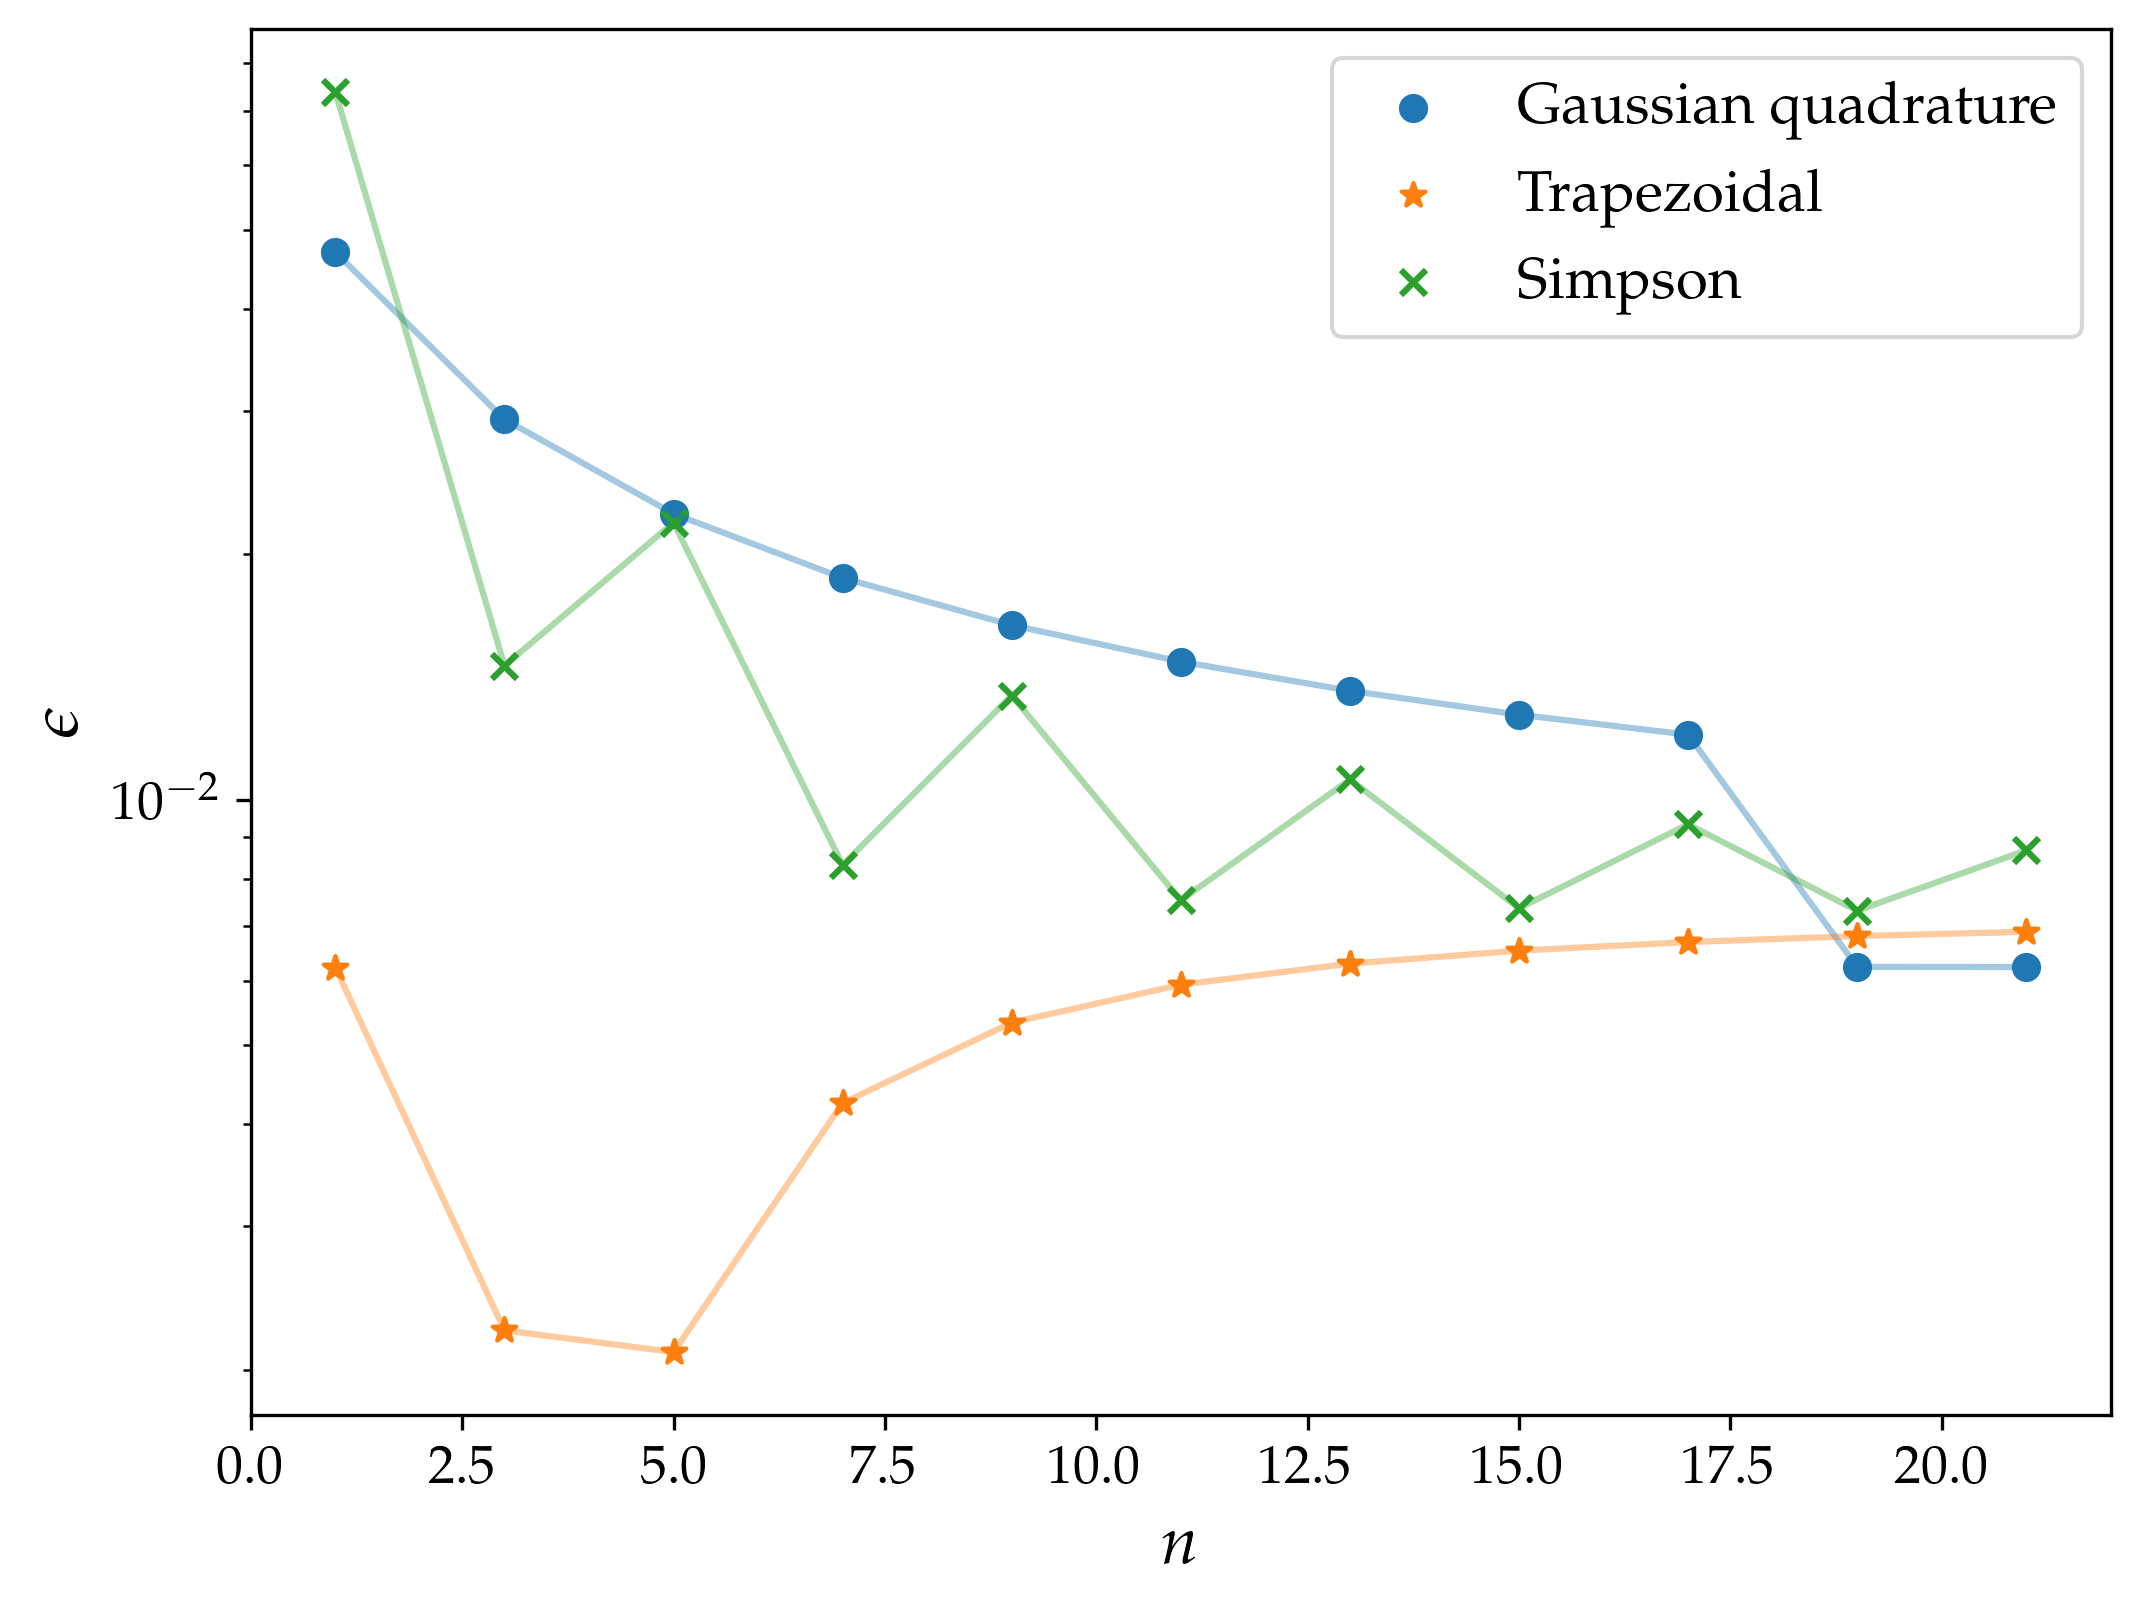

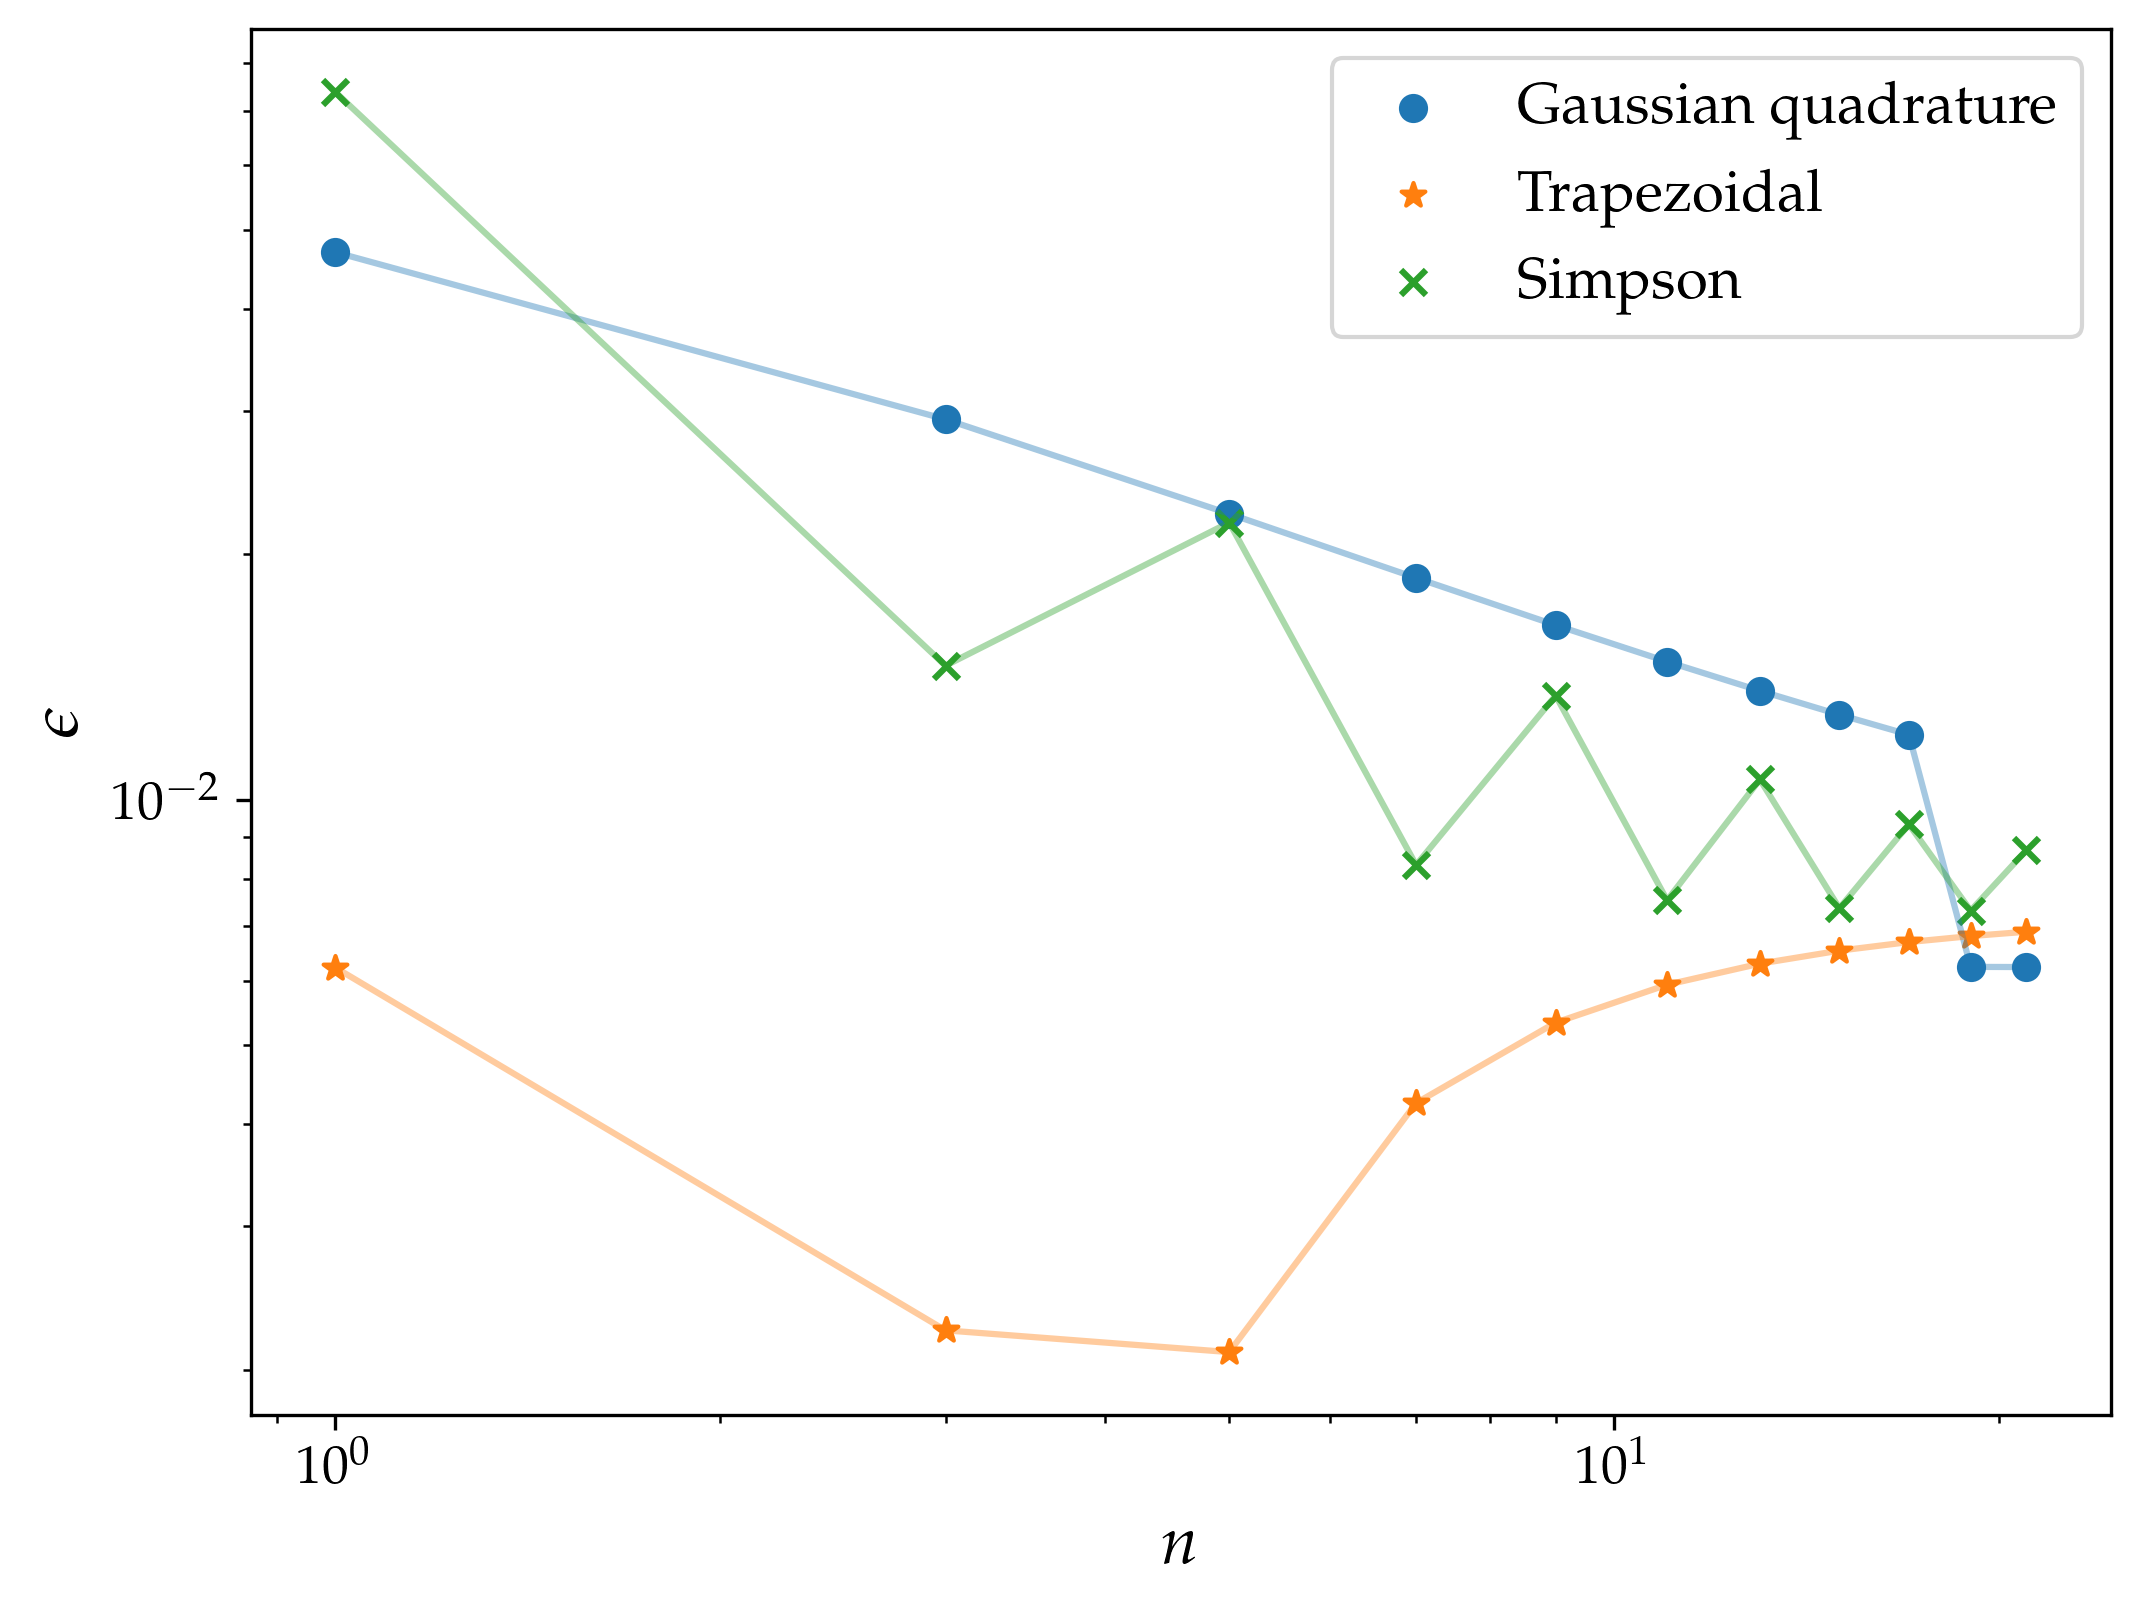

In [11]:

for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
    plt.plot(n_deg, ys, alpha=0.4)
    plt.scatter(n_deg, ys, label=names[n], marker=markers[n])
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.legend()

plt.savefig('plots/confr.png')
plt.show()

for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
    plt.plot(n_deg, ys, alpha=0.4)
    plt.scatter(n_deg, ys, label=names[n], marker=markers[n])
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.xscale('log') 
plt.legend()

plt.savefig('plots/log_confr.png')
plt.show()

## **Fit of the slope of integrals**

In [12]:
# from lib_fitting import lin_fit

# cuts = [(0, -3), (4, -1), (0, -3)]
# for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
#     lin_fit(np.log10(n_deg[cuts[n][0]: cuts[n][1]]), np.log10(ys[cuts[n][0]: cuts[n][1]]), np.eye(len(n_deg[cuts[n][0]:cuts[n][1]])), poly_order=1,
#             ErrTrue=False)

    